In [11]:
import os
import cv2
import time
import torch
import numpy as np

from ultralytics import YOLO

print("Stage 5 ready.")

Stage 5 ready.


In [12]:
# load our segmentation model
MODEL_PATH = "stage4_yolo11n_seg.pt"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found:\n{os.path.abspath(MODEL_PATH)}"
    )

seg_model = YOLO(MODEL_PATH)

print("Model loaded:")
print(os.path.abspath(MODEL_PATH))

Model loaded:
e:\Pyhton code\Deep Learning\CNN\Object Detection Project\stage4_yolo11n_seg.pt


In [16]:
# check gpu
import torch
import time

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# Check where the segmentation model is running
print("\nModel device:", next(seg_model.model.parameters()).device)

CUDA available: True
GPU: NVIDIA GeForce RTX 2050
CUDA version: 12.8

Model device: cpu


In [17]:
# set video path
VIDEO_PATH = r"C:\Users\SUYASH\Videos\WhatsApp Video 2026-03-30 at 7.45.50 PM.mp4"

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f"Video not found:\n{VIDEO_PATH}"
    )

print("Video found:")
print(VIDEO_PATH)

Video found:
C:\Users\SUYASH\Videos\WhatsApp Video 2026-03-30 at 7.45.50 PM.mp4


In [18]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Could not open video.")

FPS = cap.get(cv2.CAP_PROP_FPS)
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FRAME_COUNT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

DURATION = FRAME_COUNT / FPS if FPS > 0 else 0

print("Width     :", WIDTH)
print("Height    :", HEIGHT)
print("FPS       :", round(FPS, 2))
print("Frames    :", FRAME_COUNT)
print("Duration  :", round(DURATION, 2), "seconds")

Width     : 848
Height    : 478
FPS       : 29.47
Frames    : 858
Duration  : 29.11 seconds


In [19]:
TARGET_CLASS = "person"

OPERATION = "blur"

CONFIDENCE = 0.35

IMAGE_SIZE = 320

In [20]:
OUTPUT_VIDEO = (
    f"stage5_{OPERATION}_{TARGET_CLASS}.mp4"
)

print("Output video:")
print(os.path.abspath(OUTPUT_VIDEO))

Output video:
e:\Pyhton code\Deep Learning\CNN\Object Detection Project\stage5_blur_person.mp4


In [21]:
# optimized video processor

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Could not open input video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    fourcc,
    fps,
    (width, height)
)

if not writer.isOpened():
    cap.release()
    raise RuntimeError(
        "Could not create output video."
    )

# --------------------------------------------
# Start YOLO tracking ONCE
# --------------------------------------------

results_stream = seg_model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    conf=CONFIDENCE,
    imgsz=IMAGE_SIZE,
    device=0,
    stream=True,
    persist=True,
    verbose=False
)

start_time = time.time()
processed_frames = 0

# --------------------------------------------
# Process streamed frames
# --------------------------------------------

for result in results_stream:

    processed_frames += 1

    # Original frame
    frame = result.orig_img.copy()

    # ----------------------------------------
    # TRACK MODE
    # ----------------------------------------

    if OPERATION == "track":

        output = result.plot()

    # ----------------------------------------
    # BLUR / HIGHLIGHT
    # ----------------------------------------

    else:

        output = frame.copy()

        if (
            result.boxes is not None
            and result.masks is not None
        ):

            for i, box in enumerate(result.boxes):

                class_id = int(
                    box.cls.item()
                )

                class_name = (
                    result.names[class_id]
                )

                confidence = float(
                    box.conf.item()
                )

                # Only process target class
                if (
                    class_name.lower()
                    != TARGET_CLASS.lower()
                ):
                    continue

                if confidence < CONFIDENCE:
                    continue

                # --------------------------------
                # Get segmentation mask
                # --------------------------------

                mask = (
                    result.masks.data[i]
                    .cpu()
                    .numpy()
                )

                mask = cv2.resize(
                    mask,
                    (width, height),
                    interpolation=cv2.INTER_NEAREST
                )

                mask = mask > 0.5

                # --------------------------------
                # BLUR
                # --------------------------------

                if OPERATION == "blur":

                    blurred = cv2.GaussianBlur(
                        frame,
                        (41, 41),
                        0
                    )

                    output[mask] = (
                        blurred[mask]
                    )

                # --------------------------------
                # HIGHLIGHT
                # --------------------------------

                elif OPERATION == "highlight":

                    darkened = (
                        frame.astype(np.float32)
                        * 0.25
                    ).astype(np.uint8)

                    output = darkened

                    output[mask] = frame[mask]

        # ----------------------------------------
        # Add small progress label
        # ----------------------------------------

        cv2.putText(
            output,
            f"{TARGET_CLASS} | {OPERATION}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (255, 255, 255),
            2
        )

    # ----------------------------------------
    # Write frame
    # ----------------------------------------

    writer.write(output)

    # ----------------------------------------
    # Progress
    # ----------------------------------------

    if processed_frames % 30 == 0:

        elapsed = time.time() - start_time

        current_fps = (
            processed_frames / elapsed
            if elapsed > 0
            else 0
        )

        remaining = (
            FRAME_COUNT - processed_frames
        )

        eta = (
            remaining / current_fps
            if current_fps > 0
            else 0
        )

        print(
            f"Frame {processed_frames}/{FRAME_COUNT} | "
            f"Speed: {current_fps:.2f} FPS | "
            f"ETA: {eta:.1f}s"
        )

# --------------------------------------------
# Cleanup
# --------------------------------------------

writer.release()
cap.release()

elapsed = time.time() - start_time

print("\n==============================")
print("VIDEO PROCESSING COMPLETE")
print("==============================")
print("Frames processed:", processed_frames)
print("Time:", round(elapsed, 2), "seconds")
print(
    "Processing FPS:",
    round(processed_frames / elapsed, 2)
)
print("Output:", os.path.abspath(OUTPUT_VIDEO))

Frame 30/858 | Speed: 5.39 FPS | ETA: 153.7s
Frame 60/858 | Speed: 5.47 FPS | ETA: 145.9s
Frame 90/858 | Speed: 5.53 FPS | ETA: 138.9s
Frame 120/858 | Speed: 5.56 FPS | ETA: 132.7s
Frame 150/858 | Speed: 5.62 FPS | ETA: 125.9s
Frame 180/858 | Speed: 5.43 FPS | ETA: 124.9s
Frame 210/858 | Speed: 5.47 FPS | ETA: 118.5s
Frame 240/858 | Speed: 5.58 FPS | ETA: 110.8s
Frame 270/858 | Speed: 5.70 FPS | ETA: 103.1s
Frame 300/858 | Speed: 5.78 FPS | ETA: 96.6s
Frame 330/858 | Speed: 5.90 FPS | ETA: 89.5s
Frame 360/858 | Speed: 5.81 FPS | ETA: 85.7s
Frame 390/858 | Speed: 5.88 FPS | ETA: 79.6s
Frame 420/858 | Speed: 5.90 FPS | ETA: 74.2s
Frame 450/858 | Speed: 5.86 FPS | ETA: 69.6s
Frame 480/858 | Speed: 5.71 FPS | ETA: 66.2s
Frame 510/858 | Speed: 5.37 FPS | ETA: 64.8s
Frame 540/858 | Speed: 5.18 FPS | ETA: 61.4s
Frame 570/858 | Speed: 5.06 FPS | ETA: 56.9s
Frame 600/858 | Speed: 4.90 FPS | ETA: 52.6s
Frame 630/858 | Speed: 4.84 FPS | ETA: 47.1s
Frame 660/858 | Speed: 4.80 FPS | ETA: 41.2s
Fram

In [22]:
# verify output
if os.path.exists(OUTPUT_VIDEO):

    size_mb = (
        os.path.getsize(OUTPUT_VIDEO)
        / (1024 * 1024)
    )

    print("Output successfully created.")
    print("Path:", os.path.abspath(OUTPUT_VIDEO))
    print("Size:", round(size_mb, 2), "MB")

else:

    print("Output video was not created.")

Output successfully created.
Path: e:\Pyhton code\Deep Learning\CNN\Object Detection Project\stage5_blur_person.mp4
Size: 28.01 MB


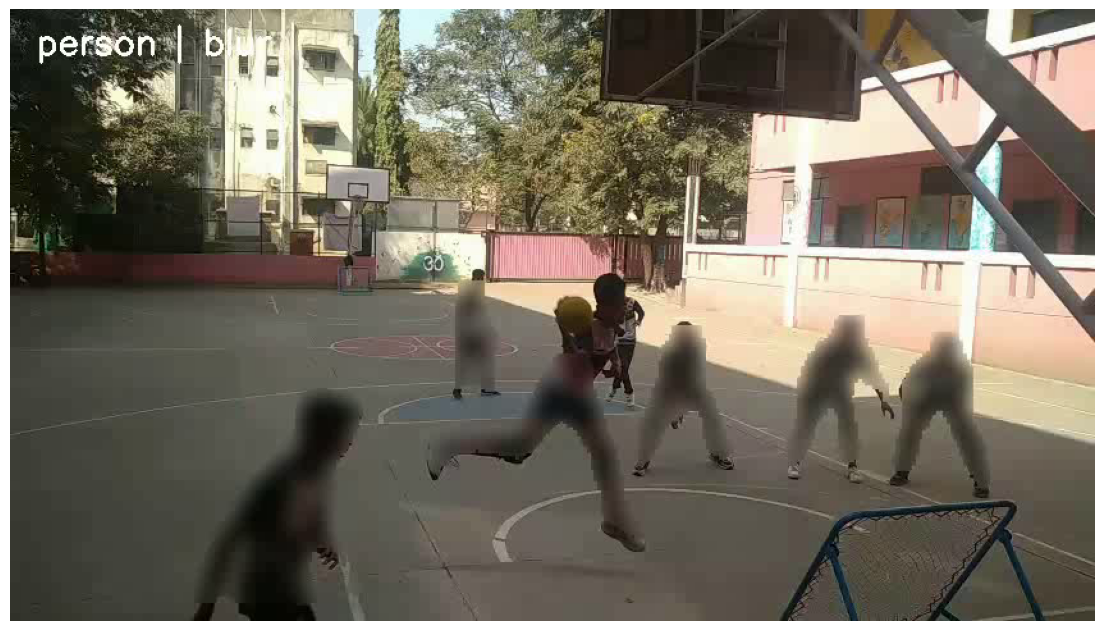

In [23]:
# test the output video
cap = cv2.VideoCapture(OUTPUT_VIDEO)

success, frame = cap.read()

cap.release()

if success:

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

else:

    print("Could not read output video.")